In [ ]:
import matplotlib.pyplot as plt
import numpy as np

## ERICCa Tutorial

This tutorial will show you how to
- Calculate eikonal phases 
- Calculate a reaction cross section using the matter densities as inputs
- Calculate a reaction cross section using the profile function densities as inputs
  
Before we start, we need to load in ERICCa to our Jupyter environment

In [ ]:
import ERICCa as ERICCa

ModuleNotFoundError: No module named 'ERICCa'

### Calculate the glabur model reaction cross section: Matter densities

ERICCa calculates cross sections in the Glauber scattering theory. To calculate something using the glauber framework, we matter densities of the target and projecitle densities as inputs. So, we first need to load in our densities into our environment. In this example, we will be calculating a $^{12}$C on $^{12}$C reaction cross section. So we will need to load $^{12}$C matter densities. I am loading in $^{12}$C matter densities calculated using the 14D Fayans energy density functions using np.genfromtxt(). The C is the density and as a function of radius r, where C_r_mesh is our corresponding r

In [ ]:
#Loading the densites
C = np.genfromtxt("Cor_dens_Update/Cor_Ca_C_Mass_dens/12Crho-mass.txt", unpack= True) 
C_r_mesh = np.genfromtxt("Cor_dens_Update/Cor_Ca_C_Mass_dens/12C_radius.txt", unpack= True)

The array C and C_r_mesh are 500 sample sets of Ca densities in the files 12Crho-mass.txt and 12Crho-mass.txt. For our calculation, we only need one set. To give you an idea of the shape of the arrays needed, the densities that we are using are printed out 

In [ ]:
print("density of 12C, 'C':", C[0])
print("for coresponding r 'C_r_mesh':", C_r_mesh[0])

density of 12C, 'C': [1.96452024e-01 1.95192097e-01 1.90806756e-01 1.82868636e-01
 1.70543830e-01 1.52917685e-01 1.29525240e-01 1.01568082e-01
 7.28273328e-02 4.77945463e-02 2.89285203e-02 1.63449384e-02
 8.78257203e-03 4.58364915e-03 2.36384294e-03 1.21783876e-03
 6.30440805e-04 3.28771586e-04 1.72846353e-04 9.15855840e-05
 4.88666671e-05 2.62188001e-05 1.41173483e-05 7.60575377e-06
 4.08112318e-06 2.16473761e-06 1.12052554e-06 5.52831420e-07
 2.47944065e-07 9.03809229e-08 1.84995857e-08]
for coresponding r 'C_r_mesh': [0.  0.3 0.6 0.9 1.2 1.5 1.8 2.1 2.4 2.7 3.  3.3 3.6 3.9 4.2 4.5 4.8 5.1
 5.4 5.7 6.  6.3 6.6 6.9 7.2 7.5 7.8 8.1 8.4 8.7 9. ]


Graphed the 12C sample looks like the following:

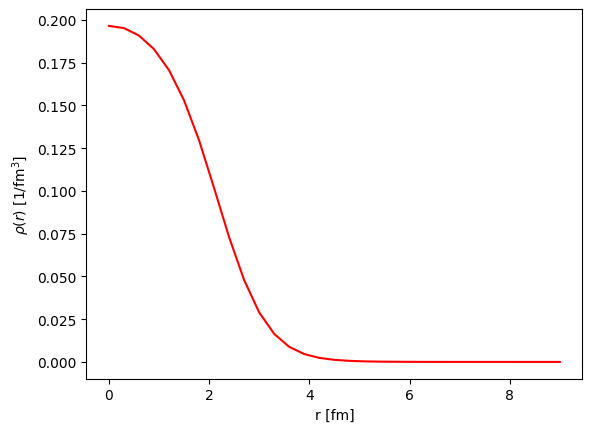

In [ ]:
plt.plot(C_r_mesh[0], C[0], color = "r" )
plt.ylabel(r"$\rho(r)$ [1/fm$^3$]")
plt.xlabel(r"r [fm]")
plt.show()

In order to calculate the reaction cross section using ERICCa we need to transform our 12C densities from $\rho(r)$ to $\rho(b)$. You can call the function ERRICa.dens_b_interpolator(), which automatically does this for you. All you have to do is call the function as follows

In [ ]:
C_rho = ERICCa.dens_b_interpolator(C_r_mesh[0],C[0])

In [ ]:
Chi_ola
chi_mol

and the density is transformed into a density as a function of impact parameter b with a mesh consistent with the mesh in ERICCa's reaction cross section calculation function. The general way we calculate the cross section with matter densities as inputs is by calling the function

    ERICCa.sigma_R( rho_t,  rho_p  = 0, Gamma = lambda b: np.exp(-b), Model = "OLA")

Where the inputs 

- rho_t: the matter density of the target as a function of impact parameter b in 1/fm$^2$.
- rho_p: the matter density of the projectile as a function of impact parameter b in 1/fm$^2$.
- Gamma: the profile function; the effective interaction between the target and projectile nucleus. 
- Model: the type of model used in the cross section calculation, either the "MOL" or the "OLA"

Say we want to calculate the reaction cross section for 12C on 12C at 300 MeV using matter densities as inputs to ERICCa.sigma_R() are relatively straightforward 

    ERICCa.sigma_R(300 ,C_rho, rho_p = C_rho, Gamma =? , Model = "MOL") 

except for the choice of profile function. For the choice of profile functions, you have two options. The first choice is to write in the form of the profile function, which is shown in the following cell.

In [ ]:
#An example of a programed example of a profile function
def Spec_Gamma(b):
    alpha_NN = 0.326
    beta_NN = 0.081
    sigma_NN = 3.7    
    return (1 -  1j * alpha_NN)/( 4 * np.pi * beta_NN) * sigma_NN * np.exp( - b**2/(2 *beta_NN) )

To calculate the reaction cross section you plug this into the ERICCa.sigma_R to get

In [ ]:
ERICCa.sigma_R(C_rho, rho_p = C_rho, Gamma = Spec_Gamma , Model = "MOL")

845.855627212321

The measured value of the reaction cross section of 12C on 12C at 300 MeV is  860 $\pm$ 50 mb, and the calculated cross section is 846 mb, which is well with in 1 sigma of our results. The ability to program your own profile function into ERICCa allows for slightly more customization of the reaction cross section, but it is not needed for all calculations. If you don't want to program a profile function, ERICCa has its own built in profile functions you can call. To do this, first call

    ERICCa.profile_funct_param(E, interaction_type = "matter")

where
- E : the reaction energy in MeV
- interaction_type : specifying whether or not your reaction is "matter", proton nucleus, or "np". The interaction_type is default set to "matter."

For our since we are using matter densities as our inputs and our reaction is at 300 MeV, we input

In [ ]:
ERICCa.profile_funct_param(300, interaction_type = "matter")

The function ERICCa.profile_funct_param writes a profile function with parameters set to the energy input in E. The profile function that was created still needs to be input to be called, which can be done by writing ERICCa.Gamma. For example 

In [ ]:
ERICCa.sigma_R(C_rho, rho_p = C_rho, Gamma = ERICCa.Gamma, Model = "MOL") 

807.975009266815

Which is just outside of the 1 sigma confidence interval. To calculate each cross section, it takes about 2 seconds.

In [ ]:
%%timeit
ERICCa.sigma_R(C_rho, rho_p = C_rho, Gamma = ERICCa.Gamma, Model = "MOL")

2.04 s ± 52.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


This allows for fast calculations for cross section predictions.

### Too Long Didn't read

Calculate the reaction cross section in 6 lines of code. 

In [ ]:
#load in Package
import ERICCa as ERICCa

#Loading the densites
C = np.genfromtxt("Cor_dens_Update/Cor_Ca_C_Mass_dens/12Crho-mass.txt", unpack= True) 
C_r_mesh = np.genfromtxt("Cor_dens_Update/Cor_Ca_C_Mass_dens/12C_radius.txt", unpack= True)

#preparing the densities to be compatable with the mesh for the cross section function
C_rho = ERICCa.dens_b_interpolator(C_r_mesh[0],C[0])
# loading in profile function built into ERICCa
ERICCa.profile_funct_param(300, interaction_type = "matter")

#Calculating the cross section
ERICCa.sigma_R(C_rho, rho_p = C_rho, Gamma = ERICCa.Gamma, Model = "MOL")

807.975009266815

## Calculate the glabur model reaction cross section: proton and neutron densities

To calculate a cross section in the Glauber framework, we need the proton and neutron densities of the target and projectile densities as inputs. So the first need to load our densities into our environment. In this example, we will be calculating a 12C on 42Ca reaction cross section. So we will need to load 12C and 42Ca proton and neutron densities. I am loading in the densities calculated using the 14D Fayans energy density functions using np.genfromtxt(). I also included the interpolation step in this section of the tutorial since it is exlained previously

In [ ]:
#Load in densities
C_r_Filename = np.array(["Cor_dens_Update/Cor_Ca_C_Mass_dens/12C_radius.txt",])     
C_p_Filename = np.array(["Cor_dens_Update/Cor_Ca_C_Mass_dens/12Crho-prot.txt",])
C_n_Filename = np.array(["Cor_dens_Update/Cor_Ca_C_Mass_dens/12Crho-neut.txt",])
C_p = np.genfromtxt(C_p_Filename[0], unpack= True)
C_r_mesh = np.genfromtxt(C_r_Filename[0], unpack= True)
C_n = np.genfromtxt(C_n_Filename[0], unpack= True)

C_rho_p = ERICCa.dens_b_interpolator(C_r_mesh[0], C_p[0]) 
C_rho_n = ERICCa.dens_b_interpolator(C_r_mesh[0], C_n[0])

Ca_r_Filename = np.array(["Cor_dens_Update/Cor_Ca_C_Mass_dens/42Ca_radius.txt",])     
Ca_p_Filename = np.array(["Cor_dens_Update/Cor_Ca_C_Mass_dens/42Carho-prot.txt",])
Ca_n_Filename = np.array(["Cor_dens_Update/Cor_Ca_C_Mass_dens/42Carho-neut.txt",])
Ca_p = np.genfromtxt(Ca_p_Filename[0], unpack= True)
Ca_r_mesh = np.genfromtxt(Ca_r_Filename[0], unpack= True)
Ca_n = np.genfromtxt(Ca_n_Filename[0], unpack= True)

Ca_rho_p = ERICCa.dens_b_interpolator(Ca_r_mesh[0], Ca_p[0]) 
Ca_rho_n = ERICCa.dens_b_interpolator(Ca_r_mesh[0], Ca_n[0])


Next to calculate the cross section. We call the function

    ERICCa.sigma_R_micro(rho_t_p, rho_t_n, rho_p_p, rho_p_n, Gamma_pp, Gamma_pn, Gamma_nn , Model = "OLA")

where

- rho_t_p: the proton density of the target as a function of impact parameter b in 1/fm$^2$
- rho_t_n: the neutron density of the target as a function of impact parameter b in 1/fm$^2$
- rho_p_n: the proton density of the projectile as a function of impact parameter b in 1/fm$^2$
- rho_p_p: the proton density of the projectile as a function of impact parameter b in 1/fm$^2$
- Gamma_pp: the proton-proton profile function
- Gamma_pn: the proton-neutron profile function
- Gamma_nn : the neutron-neutron profile function
- Model: choice of model "OLA" or "MOL"

Since a reaction cross section calculated in the Glauber framework with proton and neutron densities as inputs is not commonly enough to have a profile function filled with parameters, I have taken one from the 12C on 42-51Ca project. Basically, what we note is that there are 3 profile functions instead of 1 for the proton-proton, proton-neutron, and neutron-neutron interactions.

In [ ]:
sigma_pp = 2.385 
sigma_pn = 3.3
sigma_nn = 1.6

alpha_pp, alpha_pn, alpha_nn = 0.0013102343212775063, 0.0008692442708971146, 3.323994219176928

beta_pp = ((1 + alpha_pp**2)/(16 * np.pi)) * sigma_pp
beta_pn = ((1 + alpha_pn**2)/(16 * np.pi)) * sigma_pn
beta_nn = ((1 + alpha_nn**2)/(16 * np.pi)) * sigma_nn

        
Gamma_pp = lambda b : ((1 -  1j * alpha_pp)/( 4 * np.pi * beta_pp) ) * sigma_pp * np.exp( - b**2/(2 *beta_pp)) 
Gamma_pn = lambda b : ((1 -  1j * alpha_pn)/( 4 * np.pi * beta_pn) ) * sigma_pn * np.exp( - b**2/(2 *beta_pn))
Gamma_nn = lambda b : ((1 -  1j * alpha_nn)/( 4 * np.pi * beta_nn) ) * sigma_nn * np.exp( - b**2/(2 *beta_nn))

Then we plug the profile functions and the proton and neutron densities into the projectile into the function ERICCa.sigma_R_micro to get a cross section in mb.

In [ ]:
Chi_ola_micro
chi_mol_micro

In [ ]:
ERICCa.sigma_R_micro(C_rho_p, C_rho_n, Ca_rho_p, Ca_rho_n, Gamma_pp, Gamma_pn, Gamma_nn , Model = "OLA")

1462.2657590590745

In [ ]:
chi_no_dens

In [ ]:
%%timeit
ERICCa.sigma_R_micro(C_rho_p, C_rho_n, Ca_rho_p, Ca_rho_n, Gamma_pp, Gamma_pn, Gamma_nn , Model = "OLA")

4.18 s ± 193 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
